# A1 LFP Demo

Load one saved NetPyNE result, extract LFP as xarray, and inspect LFP, PSD, and CPSD over a shared time interval.

In [1]:
T_LIMITS = (5, 15)

LFP_TRACE_CHAN_IDX = 0
PSD_CHAN_IDX = 0
TF_CHAN_IDX = 0
CPSD_CHAN_IDXS = (0, 1)
WIN_LEN = 1.0
WIN_OVERLAP = 0.5
FMAX = 100.0

LFP_OUTLIER_Z_THRESH = 8.0
LFP_OUTLIER_REL_NEIGHBOR_THRESH = 5.0

In [2]:
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DIR_PACKAGE = Path.cwd().parent
DIR_REPO = DIR_PACKAGE.parent
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))

from sim_data_analyzer.xr_adapters import get_lfp_xr, get_net_rate_dynamics_xr
from sim_data_analyzer.xr_signal import interp_time_outliers
from sim_data_analyzer.xr_spect import calc_xr_cpsd, calc_xr_tf, calc_xr_welch

In [3]:
# Load simulation result from pkl
FPATH_SIM_RESULT = (
    DIR_PACKAGE / 'dev_scratch' / 'data_src' / 
    'a1_lfp_15s' / 'data_00000_seed_1000.pkl'
)
with FPATH_SIM_RESULT.open('rb') as fid:
    sim_result = pickle.load(fid)

print(FPATH_SIM_RESULT)
print('Duration (ms):', sim_result['simConfig']['duration'])
print('Record step (ms):', sim_result['simConfig']['recordStep'])
print('LFP samples x channels:', len(sim_result['simData']['LFP']), 'x', len(sim_result['simData']['LFP'][0]))

Tried loading an MPI library from:
libmpi.so: libmpi.so: cannot open shared object file: No such file or directory
libmpich.so: libmpich.so: cannot open shared object file: No such file or directory
Is an MPI library such as openmpi, mpich, intel-mpi or sgi-mpt installed? If yes, it may be installed in a non-standard location that you can add to LD_LIBRARY_PATH (or DYLD_LIBRARY_PATH on macOS), or on Linux or macOS you can provide a full path in MPI_LIB_NRN_PATH

/home/nnovikov/repo/sim_data_analyzer/dev_scratch/data_src/a1_lfp_15s/data_00000_seed_1000.pkl
Duration (ms): 15000.0
Record step (ms): 0.5
LFP samples x channels: 30000 x 20


In [4]:
# Extract LFP into xarray, select a time interval, and cure one-bin outliers
lfp = get_lfp_xr(sim_result)
lfp_sel = lfp.sel(time=slice(*T_LIMITS))
lfp_sel = interp_time_outliers(
    lfp_sel,
    z_thresh=LFP_OUTLIER_Z_THRESH,
    rel_neighbor_thresh=LFP_OUTLIER_REL_NEIGHBOR_THRESH,
)
#lfp_sel

In [5]:
# Reference to a channel
#lfp -= lfp.isel(y=10)

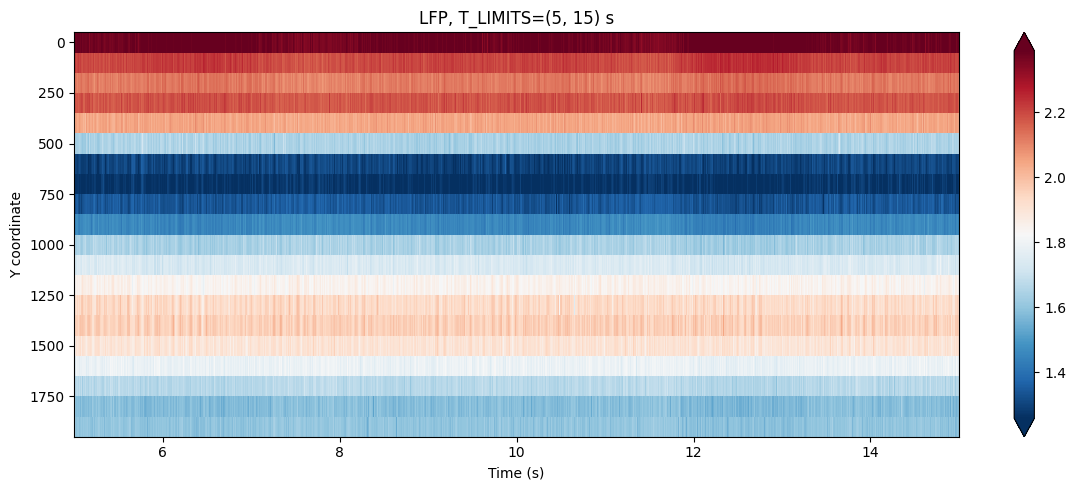

In [6]:
# Plot LFP
fig, ax = plt.subplots(figsize=(12, 5))
lfp_sel.plot(ax=ax, x='time', y='y', cmap='RdBu_r', robust=True)
ax.set_title(f'LFP, T_LIMITS={T_LIMITS} s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Y coordinate')
ax.invert_yaxis()
plt.tight_layout()

In [7]:
# Compute PSD for one LFP channel using Welch method
lfp_psd_in = lfp_sel.isel(y=PSD_CHAN_IDX)
psd = calc_xr_welch(
    lfp_psd_in,
    win_len=WIN_LEN,
    win_overlap=WIN_OVERLAP,
    fmax=FMAX,
    compute=True,
    store_proc_info=True,
)
print('PSD input y coordinate:', float(lfp_psd_in.coords['y'].item()))
#psd

PSD input y coordinate: 0.0


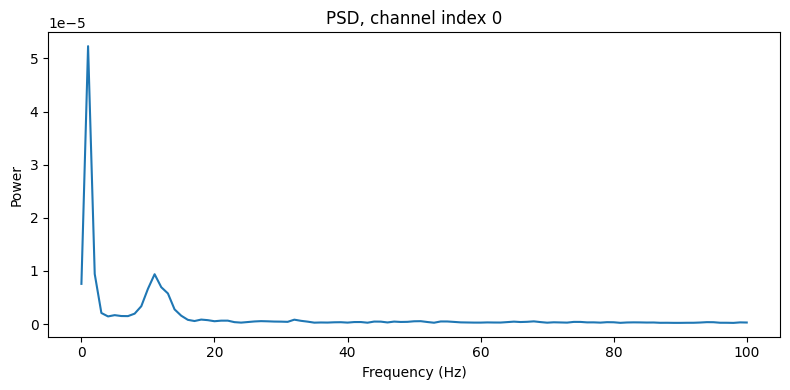

In [8]:
# Plot channel PSD
fig, ax = plt.subplots(figsize=(8, 4))
psd.plot(ax=ax)
ax.set_title(f'PSD, channel index {PSD_CHAN_IDX}')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
plt.tight_layout()

(-20.0, 1.0)

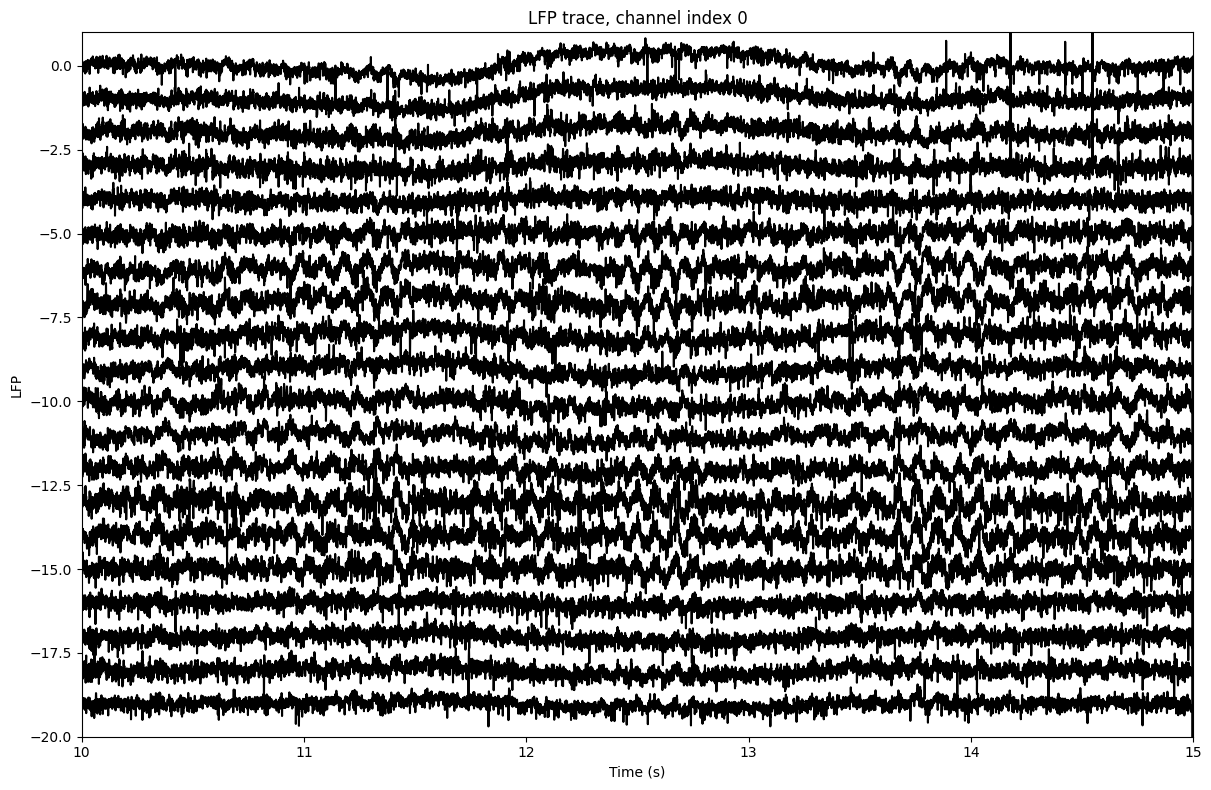

In [9]:
y_vis = lfp_sel.y.values
mult = 10

# Plot LFP channels as voltage vs. time
fig, ax = plt.subplots(figsize=(12, 8))
for n, y in enumerate(y_vis):
    v = lfp_sel.sel(y=y)
    v = (v - v.mean()) * mult - n
    v.plot(ax=ax, linestyle='-', color='k')

ax.set_title(f'LFP trace, channel index {LFP_TRACE_CHAN_IDX}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('LFP')
plt.tight_layout()

plt.xlim(10, 15)
plt.ylim(-len(y_vis), 1)

In [10]:
# Compute time-frequency transform for one LFP channel
lfp_tf_in = lfp_sel.isel(y=TF_CHAN_IDX)
tf = calc_xr_tf(
    lfp_tf_in,
    win_len=WIN_LEN,
    win_overlap=WIN_OVERLAP,
    fmax=FMAX,
    compute=True,
    store_proc_info=True,
)
#print('TF input y coordinate:', float(lfp_tf_in.coords['y'].item()))
#tf

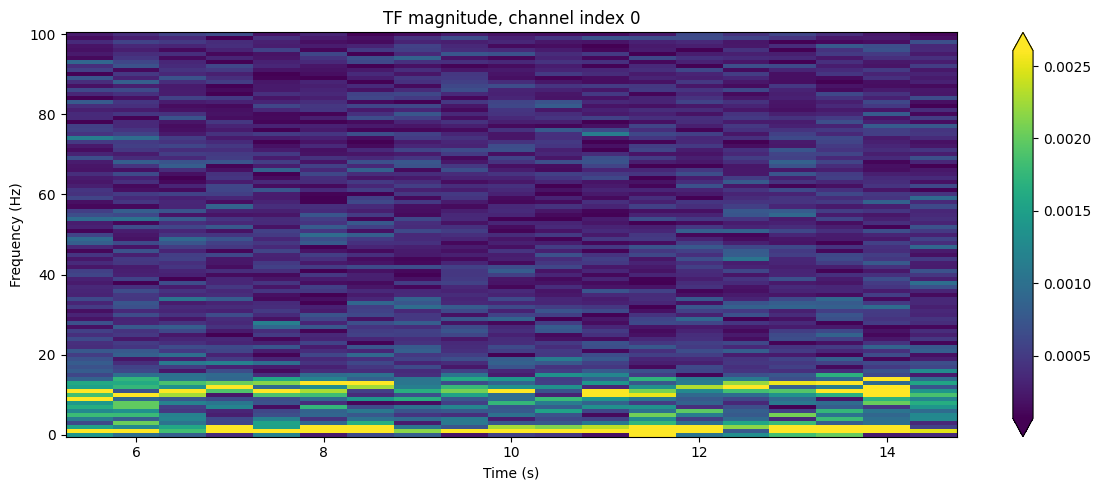

In [11]:
# Plot time-frequency transform magnitude
fig, ax = plt.subplots(figsize=(12, 5))
abs(tf).plot(ax=ax, x='time', y='freq', robust=True)
ax.set_title(f'TF magnitude, channel index {TF_CHAN_IDX}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
plt.tight_layout()

In [12]:
lfp_cpsd_1 = lfp_sel.isel(y=CPSD_CHAN_IDXS[0])
lfp_cpsd_2 = lfp_sel.isel(y=CPSD_CHAN_IDXS[1])
cpsd = calc_xr_cpsd(
    lfp_cpsd_1,
    lfp_cpsd_2,
    win_len=WIN_LEN,
    win_overlap=WIN_OVERLAP,
    fmax=FMAX,
    compute=True,
    store_proc_info=True,
)
#print('CPSD input y coordinates:', float(lfp_cpsd_1.coords['y'].item()), float(lfp_cpsd_2.coords['y'].item()))
#print(cpsd)

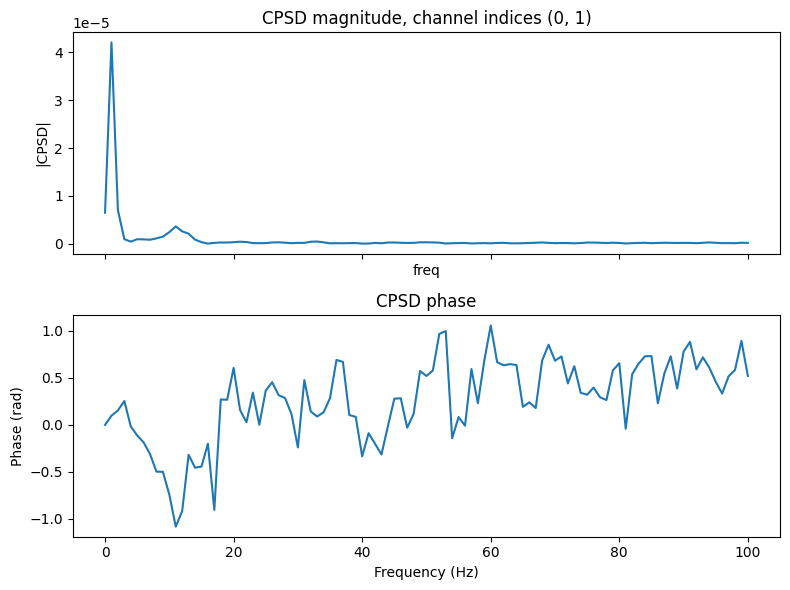

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
abs(cpsd).plot(ax=axes[0])
axes[0].set_title(f'CPSD magnitude, channel indices {CPSD_CHAN_IDXS}')
axes[0].set_ylabel('|CPSD|')
phase = xr.apply_ufunc(np.angle, cpsd)
phase.plot(ax=axes[1])
axes[1].set_title('CPSD phase')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
plt.tight_layout()

In [ ]:
net_rates = get_net_rate_dynamics_xr(
    sim_result, t_limits=(5, None))
net_rates_nofrz = net_rates.sel(pop=~net_rates.pop.str.contains('frz'))
net_rates

<xarray.DataArray (pop: 57, time: 2000)> Size: 912kB
array([[ 1.77514793,  1.77514793,  2.36686391, ...,  0.59171598,
         0.59171598,  1.18343195],
       [ 1.6139879 ,  1.6139879 ,  1.65882089, ...,  1.65882089,
         1.83815288,  1.97265187],
       [ 1.67264038,  1.43369176,  1.67264038, ...,  1.67264038,
         1.91158901,  2.15053763],
       ...,
       [ 1.78041543,  1.78041543,  1.78041543, ...,  2.57171118,
         1.97823937,  2.1760633 ],
       [20.51282051, 20.51282051, 20.51282051, ..., 15.38461538,
        10.25641026, 15.38461538],
       [ 0.95465394,  2.86396181,  1.67064439, ...,  2.38663484,
         1.43198091,  0.95465394]], shape=(57, 2000))
Coordinates:
  * pop      (pop) <U7 2kB 'IT2' 'IT3' 'ITP4' ... 'CT6frz' 'HTCfrz' 'ITS4frz'
  * time     (time) float64 16kB 5.0 5.005 5.01 5.015 ... 14.98 14.98 14.99 15.0

Text(0.5, 1.0, 'Firing rate, TC')

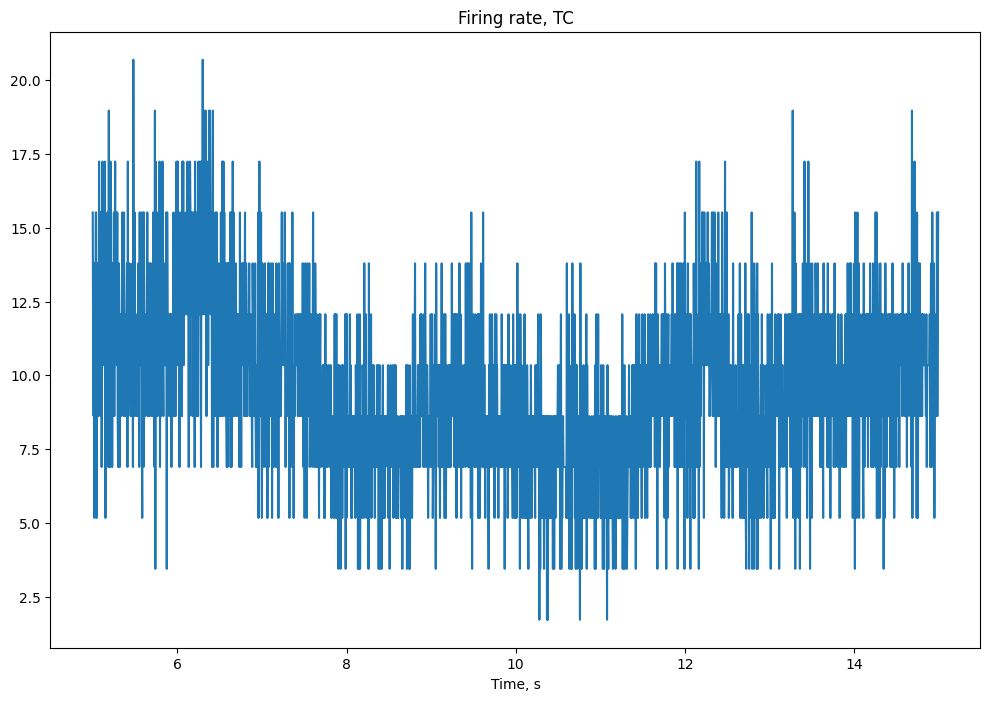

In [19]:
pop = 'TC'

fig, ax = plt.subplots(figsize=(12, 8))
net_rates.sel(pop=pop).plot(ax=ax)
ax.set_xlabel('Time, s')
ax.set_title(f'Firing rate, {pop}')

